In [1]:
# Importación de las librerías + declaración variables globales
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.preprocessing   import StandardScaler
import seaborn as sns
from sklearn.linear_model     import LinearRegression, Ridge, Lasso, RidgeCV, LassoCV, ElasticNetCV
from sklearn.model_selection  import train_test_split
from sklearn.metrics          import mean_squared_error, mean_absolute_error, r2_score

RANDOM_STATE=42

# lista con las variables más predictivas propuestas por Nando
winner_var_list = ["OverallQual","GrLivArea","TotalBsmtSF","GarageCars","YearBuilt","Neighborhood","BsmtQual","KitchenQual"]

# Lista con todas las variables categóricas que si tienen NA, indican algo diferente a valor faltante
filter_meaning = ["Alley", "BsmtQual", "BsmtCond","BsmtExposure",
                  "BsmtFinType1","BsmtFinType2","FireplaceQu",
                  "GarageType","GarageFinish","GarageQual","GarageCond",
                  "PoolQC","Fence","MiscFeature"]

In [6]:
# Carga de datos
dataset_df = pd.read_csv("../data/Project_train.csv")
dataset_df.head(3)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500


# FASE A - Análisis Exploratorio (EDA)

## Identificación de NaN
Cuidado con el valor NA. Para algunas variables indican que no tienen x cosa,
    no que falte el dato.

In [ ]:
dataset_df[winner_var_list].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   OverallQual   1460 non-null   int64 
 1   GrLivArea     1460 non-null   int64 
 2   TotalBsmtSF   1460 non-null   int64 
 3   GarageCars    1460 non-null   int64 
 4   YearBuilt     1460 non-null   int64 
 5   Neighborhood  1460 non-null   object
 6   BsmtQual      1423 non-null   object
 7   KitchenQual   1460 non-null   object
dtypes: int64(5), object(3)
memory usage: 91.4+ KB


In [ ]:
dataset_df[winner_var_list].head()

,OverallQual,GrLivArea,TotalBsmtSF,GarageCars,YearBuilt,Neighborhood,BsmtQual,KitchenQual
0,7,1710,856,2,2003,CollgCr,Gd,Gd
1,6,1262,1262,2,1976,Veenker,Gd,TA
2,7,1786,920,2,2001,CollgCr,Gd,Gd
3,7,1717,756,3,1915,Crawfor,TA,Gd
4,8,2198,1145,3,2000,NoRidge,Gd,Gd


In [ ]:
# Observación de las variables categóricas con NA, que implican valores faltantes
na_serie = dataset_df[winner_var_list].isna().sum()
na_serie[na_serie>0].drop(index=filter_meaning, errors = "ignore")

Series([], dtype: int64)

In [ ]:
# Obtención de los nombres de las variables categóricas con NA, que implican valores faltantes
columns_index_with_na = na_serie[na_serie>0].drop(index=filter_meaning, errors = "ignore").index
columns_index_with_na

Index([], dtype='object')

## Precio

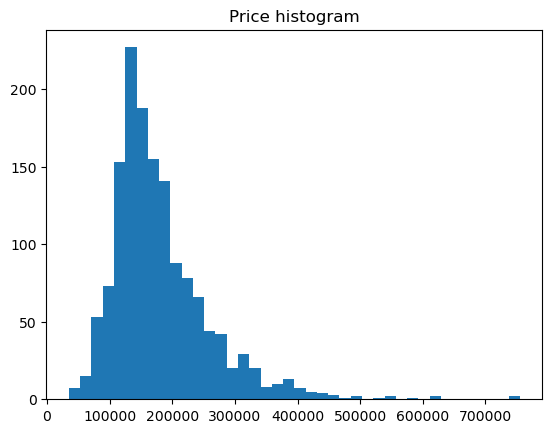

In [ ]:
plt.hist(dataset_df["SalePrice"], bins = 40)
plt.title("Price histogram")
plt.show()

# Es necesario normalizar la variable objetivo

## Observación de variables a utilizar en el modelo


### Las variables a utilizar en este modelo son:
    "OverallQual" : Variable numérica discreta del 1 al 10
    "GrLivArea" : Variable numérica continua
    "TotalBsmtSF" : Variable numérica continua
    "GarageCars" : Variable numérica discreta
    "YearBuilt" : Variable numérica discreta
    "Neighborhood" : Variable categórica nominal
    "BsmtQual" : Variable categórica ordinal
    "KitchenQual" : Variable categórica ordinal

In [ ]:
df = dataset_df.copy()
df['BsmtQual'] = df['BsmtQual'].fillna('NB')

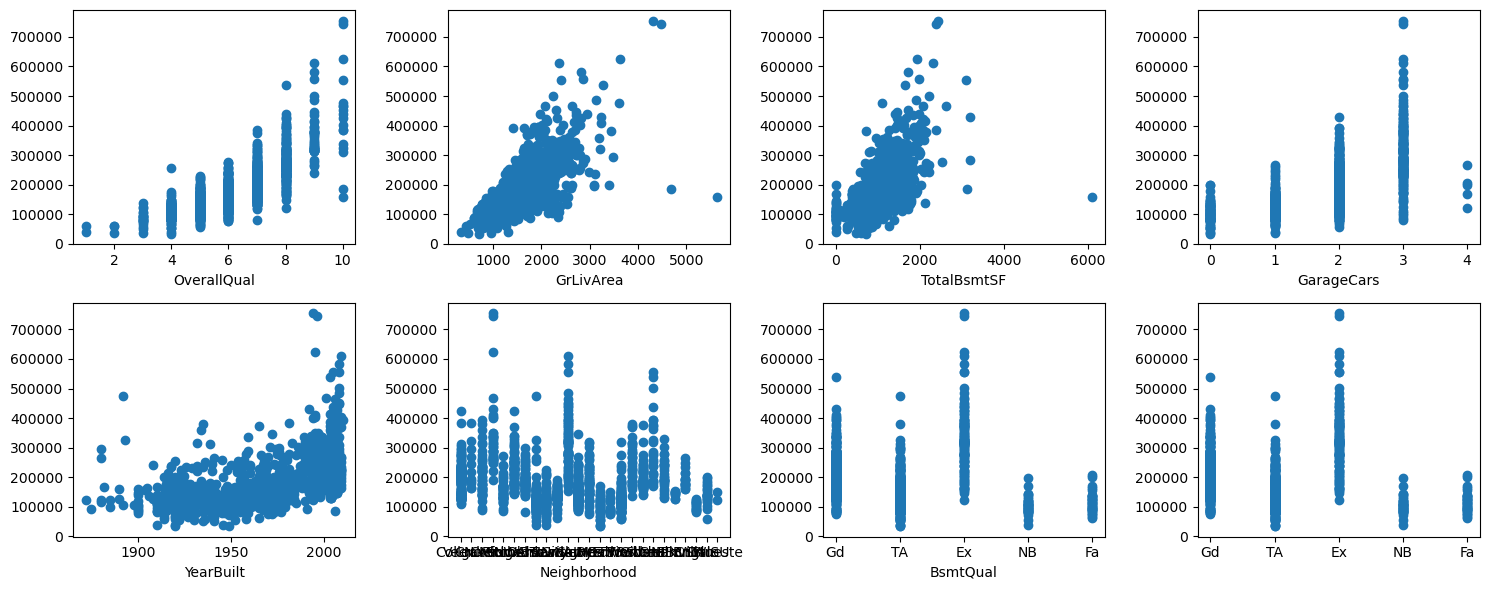

In [ ]:
atributos = winner_var_list

def dispersion():
    fig, axes = plt.subplots(ncols=4, nrows=2, figsize=(15, 6))
    for i, ax in enumerate(axes.flatten()):
        attr = atributos[i]
        if i==7:
            serie = df["BsmtQual"].fillna('NB')
            ax.scatter(serie, df.SalePrice)
        else:
            ax.scatter(df[attr], df.SalePrice)
            ax.set_xlabel(attr)

    plt.tight_layout()
    plt.show()
dispersion()

# FASE B - Limpieza y preprocesado

## Eliminación de outliers

In [ ]:
# Yo eliminaría más puntos de GrLivArea, no solo los 2 naranjas

## Normalización de variables

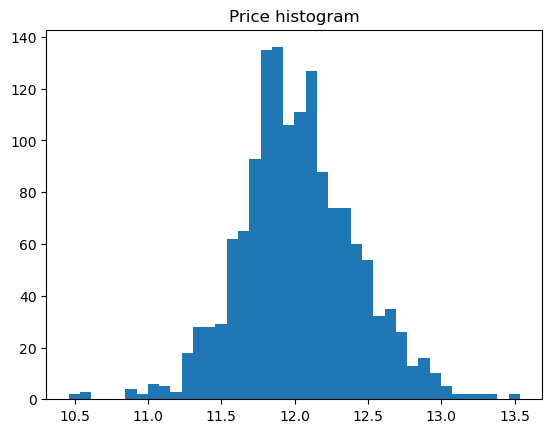

In [ ]:
# Normalización de la variable objetivo "SalePrice" PENDIENTE
plt.hist(np.log1p(dataset_df["SalePrice"]), bins = 40)
plt.title("Price histogram")
plt.show()

In [ ]:
# Sólo 1 vez
df.TotalBsmtSF =np.sqrt(df.TotalBsmtSF)
df["1stFlrSF"]= np.log(df["1stFlrSF"])
df.GrLivArea= np.log(df.GrLivArea)

# FASE C - Ingeniería de características

In [ ]:
# Áreas total, p.ej. TotalSF = GrLivArea + TotalBsmtSF + GarageArea suele ser muy predictiva. 
df["TotalSF"] = df["GrLivArea"] + df["TotalBsmtSF"] + df["GarageArea"]

# Edad de la casa: Age = YrSold − YearBuilt. Edad desde remodelación: AgeRemod = YrSold − YearRemodAdd. 
df["Age"] = df["YrSold"]-df["YearBuilt"]

# Indicadores binarios: HasPool, Has2ndFloor, IsRemodeled, HasGarage. Capturan la presencia/ausencia más que el detalle. 


# Variables de interacción: OverallQual × GrLivArea suele ser muy predictiva (calidad y tamaño actúan multiplicativamente).
print(df["TotalSF"].notna().any(), df["Age"].notna().any(), "=> Tenemos que tratar datos nulos primero")

# FASE D - Modelado

# FASE E - Validación

# FASE F - Envío y posicionamiento